# Day 015: Linear Transformations (Scaling, Rotation, Shearing)


## 1. Objective
> To construct mathematical "verbs" (transformation matrices) and apply them to multidimensional data structures to alter their geometry in vector space.

## 2. Mathematical Foundation
> A linear transformation maps a vector to a new location in space while keeping grid lines parallel and evenly spaced, and keeping the origin fixed at $(0,0)$.  
> * **The Operation:** $\mathbf{y} = \mathbf{A}\mathbf{x}$
> 
> * **Scaling:** $\mathbf{S} = \begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}$
> 
> * **Rotation:** $\mathbf{R} = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$
> 
> * **Shearing (X-axis):** $\mathbf{Sh}_x = \begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}$

## 3. Real-World & AI Applications
> * **Business Logic (Geospatial & GPS Applications):** When building the map interface for a running progress tracker tracking routes from Kathmandu to Rasuwa, raw GPS coordinates often need mathematical formatting. To align the runner's current heading to point straight "up" on a mobile UI, a **Rotation Matrix** is applied to the live coordinate array. To ensure the 15km route fits neatly within the screen dimensions, a **Scaling Matrix** adjusts the bounds.  
> 
> * **AI/ML Use Case:** If you are designing an OCR (Optical Character Recognition) model for a functional Nepali typing tool, you need robust training data. Instead of manually collecting thousands of handwriting samples, you take a single base image of a letter, then apply subtle **Shear Matrices** (to mimic italic/slanted writing) and **Rotation Matrices** (to mimic angled scans). You geometrically generate infinite training data from one source.


## 4. Algorithmic Strategy
> * **Data Organization:** We structure our coordinates as a matrix where each *column* is a point: $\begin{bmatrix} x_1 & x_2 & x_3 \\ y_1 & y_2 & y_3 \end{bmatrix}$. This allows us to transform thousands of points simultaneously using a single matrix multiplication (`A @ data`).  
> 
> * **NumPy Trig Functions:** NumPy expects angles in radians, not degrees. Always use `np.radians(degrees)` when calculating rotation matrices.

## 5. Implementation

In [1]:
import numpy as np

# ==========================================
# 5. Implementation: Building the Verbs
# ==========================================

def get_scaling_matrix(sx, sy):
    """Returns a 2x2 scaling matrix."""
    return np.array([[sx, 0.0],
                     [0.0, sy]])

def get_rotation_matrix(degrees):
    """Returns a 2x2 rotation matrix for a given angle in degrees."""
    theta = np.radians(degrees)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

def get_shear_matrix_x(k):
    """Returns a 2x2 horizontal shearing matrix."""
    return np.array([[1.0, k],
                     [0.0, 1.0]])

# Define a single point (2, 1)
point = np.array([[2.0], 
                  [1.0]])

print("--- 1. Single Point Transformations ---")
print(f"Original Point:\n{point}\n")

# Apply Scaling (Stretch x by 3, squish y by 0.5)
S = get_scaling_matrix(3, 0.5)
scaled_point = S @ point
print(f"Scaled Point (x*3, y*0.5):\n{scaled_point}\n")

# Apply Rotation (90 degrees)
R = get_rotation_matrix(90)
rotated_point = R @ point
print(f"Rotated Point (90 deg):\n{np.round(rotated_point, 5)}\n")  # Round to clean up near-zero floats

# ==========================================
# 6. Verification & Composition
# ==========================================

print("--- 2. Matrix Composition (Combining Verbs) ---")
# To Scale AND Rotate in one step, we multiply the matrices: C = R @ S
# NOTE: Order matters! R @ S means "Scale first, then Rotate".
combined_matrix = R @ S
final_point = combined_matrix @ point

print(f"Combined Matrix (Rotate(Scale(x))):\n{np.round(combined_matrix, 5)}\n")
print(f"Final Point:\n{np.round(final_point, 5)}")

--- 1. Single Point Transformations ---
Original Point:
[[2.]
 [1.]]

Scaled Point (x*3, y*0.5):
[[6. ]
 [0.5]]

Rotated Point (90 deg):
[[-1.]
 [ 2.]]

--- 2. Matrix Composition (Combining Verbs) ---
Combined Matrix (Rotate(Scale(x))):
[[ 0.  -0.5]
 [ 3.   0. ]]

Final Point:
[[-0.5]
 [ 6. ]]


## 6. Verification

Matplotlib is building the font cache; this may take a moment.


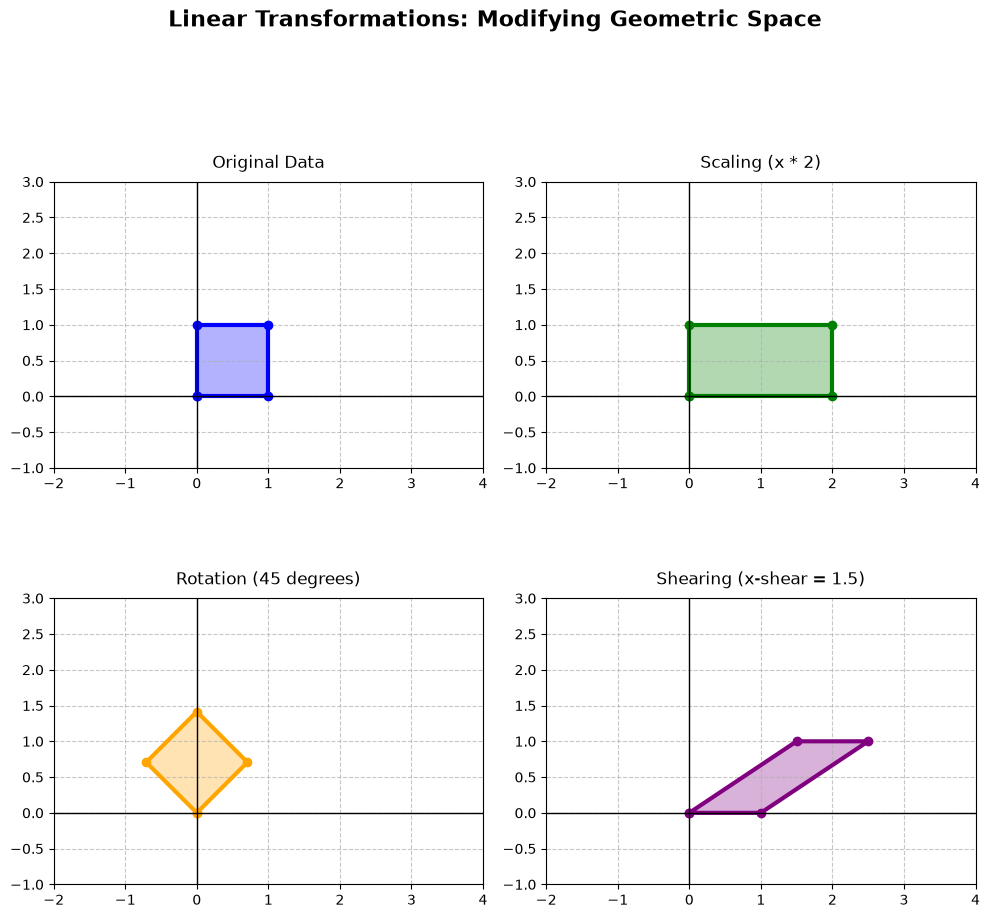

In [2]:
import numpy as np
import sys
import subprocess
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

# ==========================================
# Data Setup
# ==========================================

# A simple 1x1 square represented as coordinates
# Columns: [Bottom-Left, Bottom-Right, Top-Right, Top-Left, Close-Loop]
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

# 1. Scaling Matrix (Stretch x by 2, keep y same)
S = np.array([[2, 0],
              [0, 1]])

# 2. Rotation Matrix (45 degrees counter-clockwise)
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Shearing Matrix (X-Shear by 1.5)
Sh = np.array([[1, 1.5],
               [0, 1]])

# Apply transformations (Matrix @ Data)
scaled_square = S @ square
rotated_square = R @ square
sheared_square = Sh @ square

# ==========================================
# Plotting
# ==========================================

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Linear Transformations: Modifying Geometric Space", fontsize=16, weight='bold')

def plot_shape(ax, data, title, color):
    ax.plot(data[0, :], data[1, :], color=color, linewidth=3, marker='o')
    ax.fill(data[0, :], data[1, :], color=color, alpha=0.3)
    ax.set_title(title, pad=10)
    
    # Keep grid fixed to see the relative transformation
    ax.set_xlim(-2, 4)
    ax.set_ylim(-1, 3)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')

# Plot Original
plot_shape(axs[0, 0], square, "Original Data", 'blue')

# Plot Scaled
plot_shape(axs[0, 1], scaled_square, "Scaling (x * 2)", 'green')

# Plot Rotated
plot_shape(axs[1, 0], rotated_square, "Rotation (45 degrees)", 'orange')

# Plot Sheared
plot_shape(axs[1, 1], sheared_square, "Shearing (x-shear = 1.5)", 'purple')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 7. Complexity Analysis
- **Time Complexity:** `O(...)` *(Explain why)*
- **Space Complexity:** `O(...)` *(Explain why)*